<a href="https://colab.research.google.com/github/viniciusdevrr/deteccao-fraude-cartao/blob/main/deteccao_fraude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecção de fraude em cartões de crédito

Projeto de classificação com dados desbalanceados. **Objetivo:** identificar fraudes (`Class = 1`) e comparar modelos priorizando recall, sem ignorar precisão e F1. Execute em **Ambiente de execução → Executar tudo** no Google Colab. A base é baixada em tempo de execução e não deve ser versionada no GitHub.

**Fonte:** [Kaggle — Credit Card Fraud Detection (mlg-ulb)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). As variáveis `V1` a `V28` são componentes PCA anonimizados; não é possível atribuir a elas um significado de negócio específico.

In [10]:
%pip -q install kagglehub xgboost shap

## 1. Bibliotecas e carregamento

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_fscore_support, roc_curve, auc,
                             precision_recall_curve, average_precision_score, roc_auc_score)
from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42
folder = Path(kagglehub.dataset_download('mlg-ulb/creditcardfraud'))
files = list(folder.rglob('creditcard.csv'))
if not files:
    raise FileNotFoundError('creditcard.csv não encontrado no download do Kaggle.')
df = pd.read_csv(files[0])
print('Dimensões:', df.shape)
display(df.head())

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dimensões: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dimensões: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Exploração e desbalanceamento

In [ ]:
display(df.info())
display(df['Class'].value_counts().rename(index={0:'Normal', 1:'Fraude'}).to_frame('Quantidade'))
print('Fraudes (%):', round(df['Class'].mean()*100, 4))
print('Valores ausentes:', int(df.isna().sum().sum()))
ax = df['Class'].value_counts().sort_index().plot.bar(title='Distribuição das classes', rot=0)
ax.set_xticklabels(['Normal (0)', 'Fraude (1)']); ax.set_ylabel('Transações'); plt.show()

## 3. Preparação

Criamos `log_amount` com `log1p`, que admite valor zero. A divisão estratificada preserva aproximadamente a proporção de fraudes. O escalonamento é ajustado **somente no treino** por meio do pipeline, evitando vazamento de dados.

In [13]:
data = df.copy()
data['log_amount'] = np.log1p(data['Amount'].clip(lower=0))
X = data.drop(columns=['Class'])
y = data['Class'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print('Treino:', X_train.shape, '| Fraudes:', int(y_train.sum()))
print('Teste:', X_test.shape, '| Fraudes:', int(y_test.sum()))
print('Proporções:', y_train.mean(), y_test.mean())

Treino: (227845, 31) | Fraudes: 394
Teste: (56962, 31) | Fraudes: 98
Proporções: 0.001729245759178389 0.0017204452090867595


## 4. Treinamento

`class_weight="balanced"` e `scale_pos_weight` dão maior peso à classe rara. O teste permanece com sua distribuição original. Não fazemos reamostragem do teste.

In [5]:
positive_weight = (y_train == 0).sum() / (y_train == 1).sum()
models = {
    'Regressão Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))]),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=12, min_samples_leaf=2,
        class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        n_estimators=150, max_depth=4, learning_rate=0.08, subsample=0.9,
        colsample_bytree=0.9, scale_pos_weight=positive_weight,
        eval_metric='logloss', tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE)
}
# Validação separada para escolher o limiar sem consultar os rótulos do teste.
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=RANDOM_STATE)
for name, model in models.items():
    print('Treinando:', name)
    model.fit(X_fit, y_fit)
print('Treinamento concluído.')

Treinando: Regressão Logística
Treinando: Random Forest
Treinando: XGBoost
Treinamento concluído.


## 5. Escolha do limiar na validação

Para um critério explícito e reproduzível, selecionamos, em cada modelo, o limiar com maior **F2** na validação (F2 dá mais peso ao recall que à precisão). Em caso de empate, usamos o primeiro máximo. O teste fica reservado para avaliação final.

In [6]:
def choose_threshold(y_true, probabilities):
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    p, r = precision[:-1], recall[:-1]
    f2 = np.divide(5*p*r, 4*p+r, out=np.zeros_like(p), where=(4*p+r)>0)
    idx = int(np.argmax(f2))
    return float(thresholds[idx]), float(f2[idx])

thresholds = {}
for name, model in models.items():
    prob_val = model.predict_proba(X_val)[:, 1]
    threshold, f2 = choose_threshold(y_val, prob_val)
    thresholds[name] = threshold
    print(f'{name}: limiar={threshold:.5f}; F2 validação={f2:.4f}')

Regressão Logística: limiar=0.99962; F2 validação=0.7711
Random Forest: limiar=0.20738; F2 validação=0.8025
XGBoost: limiar=0.85610; F2 validação=0.7928


## 6. Avaliação final no teste

As métricas da tabela são exclusivamente da **classe fraude (1)**. A acurácia isolada é inadequada para esta base desbalanceada.

In [7]:
rows = []
probs_test = {}
for name, model in models.items():
    prob = model.predict_proba(X_test)[:, 1]
    probs_test[name] = prob
    pred = (prob >= thresholds[name]).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, pred, labels=[1], zero_division=0)
    rows.append({'Modelo':name, 'Limiar':thresholds[name], 'Precisão fraude':precision[0],
                 'Recall fraude':recall[0], 'F1 fraude':f1[0],
                 'ROC AUC':roc_auc_score(y_test, prob),
                 'Average Precision':average_precision_score(y_test, prob)})
    print('\n', name)
    print(classification_report(y_test, pred, target_names=['Normal', 'Fraude'], zero_division=0))
results = pd.DataFrame(rows).set_index('Modelo')
display(results.round(4))


 Regressão Logística
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.65      0.84      0.73        98

    accuracy                           1.00     56962
   macro avg       0.82      0.92      0.86     56962
weighted avg       1.00      1.00      1.00     56962


 Random Forest
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.64      0.88      0.74        98

    accuracy                           1.00     56962
   macro avg       0.82      0.94      0.87     56962
weighted avg       1.00      1.00      1.00     56962


 XGBoost
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.78      0.85      0.81        98

    accuracy                           1.00     56962
   macro avg       0.89      0.92      0.91     56962
weighted avg       1.00   

,Limiar,Precisão fraude,Recall fraude,F1 fraude,ROC AUC,Average Precision
Modelo,,,,,,
Regressão Logística,0.9996,0.6457,0.8367,0.7289,0.974,0.7116
Random Forest,0.2074,0.6418,0.8776,0.7414,0.968,0.8364
XGBoost,0.8561,0.7830,0.8469,0.8137,0.977,0.8420


## 7. Matriz de confusão e curvas

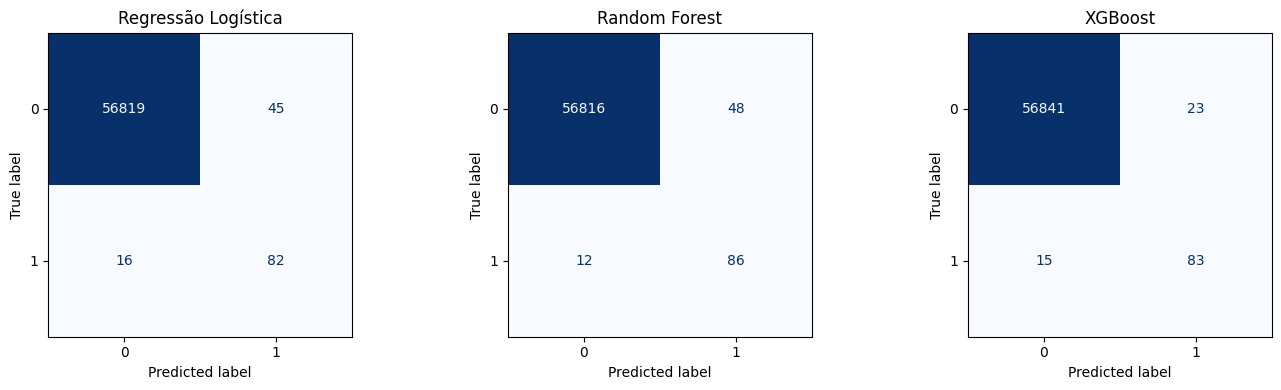

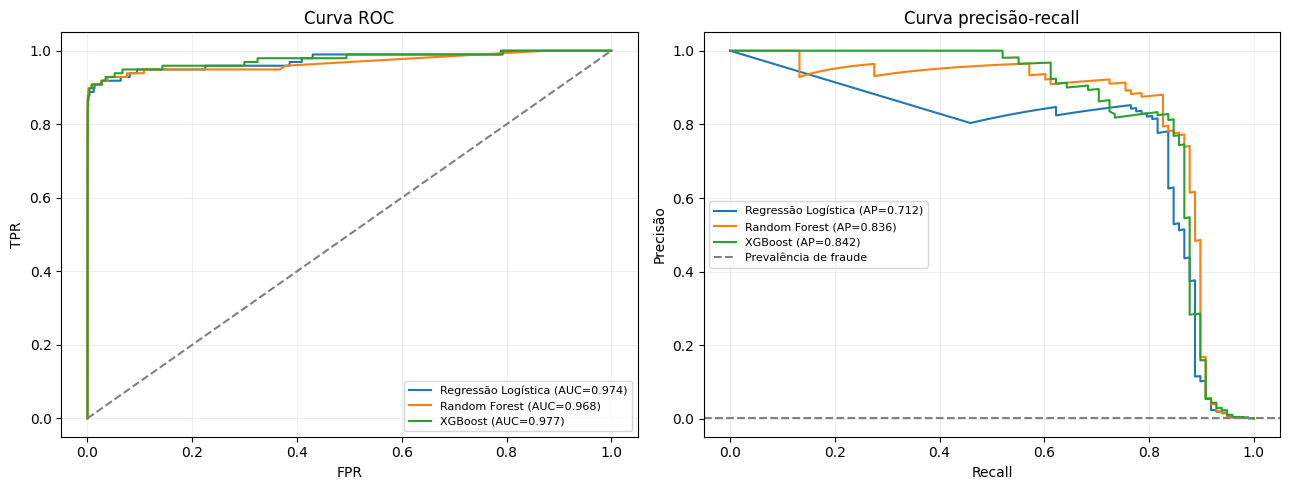

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, prob) in zip(axes, probs_test.items()):
    pred = (prob >= thresholds[name]).astype(int)
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, prob in probs_test.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    prec, rec, _ = precision_recall_curve(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
    axes[1].plot(rec, prec, label=f'{name} (AP={average_precision_score(y_test,prob):.3f})')
axes[0].plot([0,1],[0,1],'--',color='gray'); axes[0].set(title='Curva ROC',xlabel='FPR',ylabel='TPR')
axes[1].axhline(y_test.mean(), ls='--', color='gray', label='Prevalência de fraude')
axes[1].set(title='Curva precisão-recall',xlabel='Recall',ylabel='Precisão')
for ax in axes: ax.legend(fontsize=8); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()

## 8. Importância das variáveis e SHAP

Para manter a execução rápida, o SHAP é calculado em uma amostra de até 100 transações do teste usando XGBoost. Valores SHAP positivos para a classe fraude elevam a saída bruta do modelo; negativos a reduzem. As componentes PCA não possuem interpretação semântica direta.

,Importância XGBoost
V14,0.357366
V10,0.080342
V4,0.054780
log_amount,0.046267
V8,0.043043
V13,0.036267
V12,0.033000
Amount,0.030615
V20,0.025966
V26,0.024335


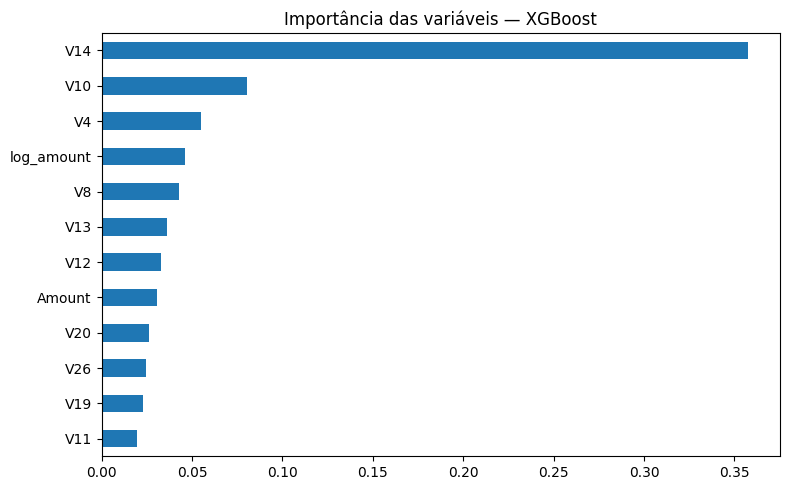

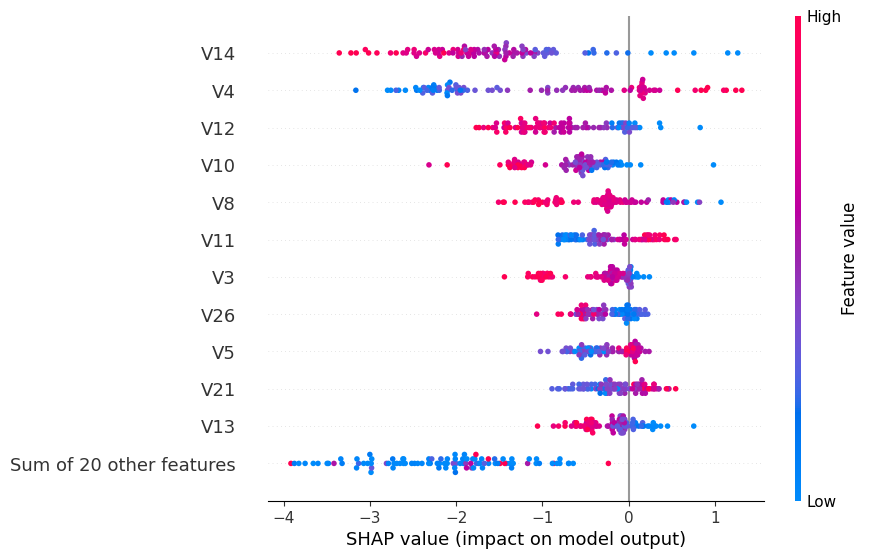

Exemplo de explicação individual:


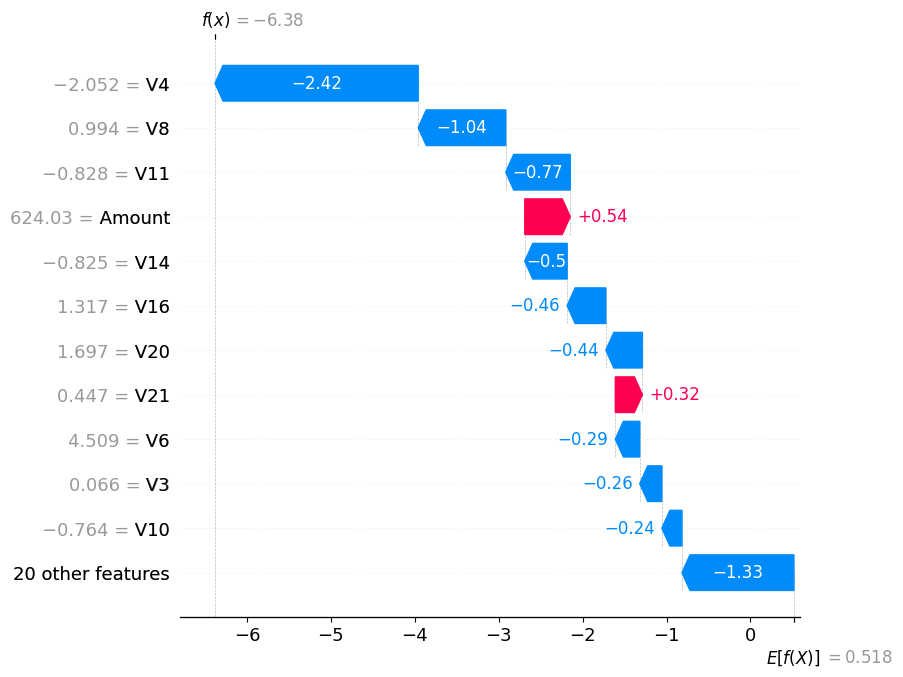

In [9]:
xgb = models['XGBoost']
importance = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
display(importance.head(12).to_frame('Importância XGBoost'))
importance.head(12).sort_values().plot.barh(figsize=(8,5), title='Importância das variáveis — XGBoost')
plt.tight_layout(); plt.show()

sample = X_test.sample(n=min(100, len(X_test)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(sample)
shap.plots.beeswarm(shap_values, max_display=12, show=True)
print('Exemplo de explicação individual:')
shap.plots.waterfall(shap_values[0], max_display=12, show=True)

## 9. Conclusões e adaptações

- A proporção de fraude é muito baixa, por isso avaliamos recall, precisão, F1 e a curva precisão-recall, em vez de usar apenas acurácia.
- Comparamos regressão logística, Random Forest e XGBoost com ponderação das classes.
- **Adaptação em relação ao roteiro do desafio:** separamos validação do teste e escolhemos o limiar maximizando F2 na validação, evitando ajustar o limiar diretamente no teste. Também adicionamos `log_amount`.
- A escolha de um limiar operacional real exige considerar o custo de falsos positivos e fraudes não detectadas. Os valores concretos estão na tabela produzida acima.
- SHAP explica contribuições do modelo, não prova causalidade. Variáveis PCA não permitem interpretar diretamente o comportamento do titular.